In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
from datetime import datetime
from pathlib import Path


In [2]:
# Mount Google Drive only when running on Colab; on a local machine this is a no-op.
try:
    from google.colab import drive
    drive.mount('/content/drive')
    ON_COLAB = True
except ImportError:
    ON_COLAB = False
    print('Not running on Colab — skipping drive.mount.')

Not running on Colab — skipping drive.mount.


In [3]:
# Set this to your dataset root directory.
# Expected structure: DATA_DIR / <emperor_folder> / side_a / *.jpg
# (e.g. DATA_DIR / 01_Augustus / side_a / *.jpg)
if ON_COLAB:
    DATA_DIR = r'/content/drive/MyDrive/coin_dataset'
else:
    DATA_DIR = r'/home/david/coin/FOR_TRAINNING'

In [4]:
# Build the same label encoder that the original notebook used when extracting embeddings,
# so the ids stored inside cradio_v4_embeddings.pt still line up with class names.
def folder_label(name):
    return re.sub(r'^\d+_', '', name)

unique_labels = sorted({folder_label(p.name) for p in Path(DATA_DIR).iterdir()
                        if p.is_dir() and (p / 'side_a').exists()})
label_encoder = {name: i for i, name in enumerate(unique_labels)}
num_classes = len(label_encoder)
print(f'{num_classes} classes from folder structure.')


52 classes from folder structure.


In [5]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print('Device:', device)


Device: cuda:0


In [6]:
# Reuse the cached embeddings produced by emp_model_v2.ipynb — no re-extraction needed.
embeddings_path = Path(DATA_DIR) / 'cradio_v4_embeddings.pt'
saved = torch.load(embeddings_path)
all_feats, all_labs = saved['features'], saved['labels']
print(f'Loaded embeddings: {all_feats.shape}')


Loaded embeddings: torch.Size([62364, 2560])


In [7]:
# Merge selected classes WITHOUT re-running feature extraction.
# We just rewrite the label ids stored in `all_labs` and compact the label space.
# MERGES maps source_class_name -> target_class_name. Both must already exist in
# the label_encoder built from the folder structure.
MERGES = {
    'GORDIAN II': 'GORDIAN I',  # very few samples / hard to distinguish — fold into GORDIAN I
}

# 1. rewrite stored label ids: every source idx becomes the target idx
remap = {label_encoder[src]: label_encoder[tgt] for src, tgt in MERGES.items()}
mapped = all_labs.clone()
for src_idx, tgt_idx in remap.items():
    mapped[all_labs == src_idx] = tgt_idx

# 2. drop the merged source names and reindex 0..N-1
kept_names = [n for n in unique_labels if n not in MERGES]
new_label_encoder = {name: i for i, name in enumerate(kept_names)}
old_to_new = {label_encoder[name]: new_label_encoder[name] for name in kept_names}

all_labs = torch.tensor([old_to_new[int(x)] for x in mapped], dtype=torch.long)

# refresh the globals the rest of the notebook uses
label_encoder = new_label_encoder
idx_to_label = {v: k for k, v in label_encoder.items()}
num_classes = len(label_encoder)

print(f'After merge: {num_classes} classes (was {num_classes + len(MERGES)}).')
for src, tgt in MERGES.items():
    print(f'  merged "{src}" -> "{tgt}" (new id {label_encoder[tgt]})')
print(f'Labels tensor: {all_labs.shape}, max id: {int(all_labs.max())}')

After merge: 51 classes (was 52).
  merged "GORDIAN II" -> "GORDIAN I" (new id 22)
Labels tensor: torch.Size([62364]), max id: 50


In [8]:
# Split embeddings into train / val / test
train_feats, test_feats, train_labs, test_labs = train_test_split(
    all_feats, all_labs, test_size=0.2, shuffle=True, stratify=all_labs, random_state=42)
train_feats, val_feats, train_labs, val_labs = train_test_split(
    train_feats, train_labs, test_size=0.2, shuffle=True, stratify=train_labs, random_state=42)

print(f'Train: {train_feats.shape[0]}  Val: {val_feats.shape[0]}  Test: {test_feats.shape[0]}')

# Build DataLoaders
batch_size = 256
train_loader = DataLoader(TensorDataset(train_feats, train_labs), batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(TensorDataset(val_feats,   val_labs),   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(TensorDataset(test_feats,  test_labs),  batch_size=batch_size, shuffle=False)

# Class weights for imbalanced data
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labs.numpy()),
    y=train_labs.numpy()
)
class_weights = torch.FloatTensor(class_weights).to(device)
print('Loaders and class weights ready.')

Train: 39912  Val: 9979  Test: 12473
Loaders and class weights ready.


In [10]:
# Train / Val / Test image counts per emperor (uses the split just produced above)
name_to_prefix = {
    re.sub(r'^\d+_', '', p.name): int(re.match(r'^(\d+)_', p.name).group(1))
    for p in Path(DATA_DIR).iterdir()
    if p.is_dir() and (p / 'side_a').exists()
}

def counts(labs):
    return pd.Series(labs.numpy()).value_counts()

train_c, val_c, test_c = counts(train_labs), counts(val_labs), counts(test_labs)
rows = []
for cls_idx in sorted(set(train_c.index) | set(val_c.index) | set(test_c.index)):
    name = idx_to_label[int(cls_idx)]
    rows.append((
        name_to_prefix.get(name, 99),
        name,
        int(train_c.get(cls_idx, 0)),
        int(val_c.get(cls_idx, 0)),
        int(test_c.get(cls_idx, 0)),
    ))
rows.sort()  # chronological by emperor number

per_class_counts = pd.DataFrame(rows, columns=['#', 'Emperor', 'Train', 'Val', 'Test'])
per_class_counts['Total'] = per_class_counts[['Train', 'Val', 'Test']].sum(axis=1)
print(per_class_counts.to_string(index=False))
print(f'\nTotals -> Train: {per_class_counts.Train.sum()}  Val: {per_class_counts.Val.sum()}  Test: {per_class_counts.Test.sum()}  ({len(per_class_counts)} classes)')


 #           Emperor  Train  Val  Test  Total
 1          AUGUSTUS   1080  270   338   1688
 2          TIBERIUS    528  132   165    825
 3          CALIGULA    506  126   158    790
 4          CLAUDIUS    884  221   276   1381
 5              NERO    958  239   299   1496
 6             GALBA    995  249   311   1555
 7              OTHO    411  103   129    643
 8         VITELLIUS    570  143   178    891
 9         VESPASIAN   1361  341   426   2128
10             TITUS   1123  281   351   1755
11          DOMITIAN   1313  329   410   2052
12             NERVA   1106  276   345   1727
13            TRAJAN   1066  267   333   1666
14           HADRIAN   1201  301   375   1877
15    ANTONINUS PIUS    613  153   192    958
16   MARCUS AURELIUS   1141  285   356   1782
17      LUCIUS VERUS    786  196   246   1228
18          COMMODUS   1125  281   351   1757
19          PERTINAX    992  248   310   1550
20   DIDIUS JULIANUS    507  127   159    793
21  SEPTIMUS SEVERUS   1553  388  

In [9]:
# Linear classification head
feat_dim = train_feats.shape[1]  # 1280 for ViT-H
head = nn.Linear(feat_dim, num_classes).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(head.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5, verbose=True)
print(f'Head: {feat_dim} -> {num_classes}')

Head: 2560 -> 51


/home/david/.local/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


In [25]:
epochs = 100
best_val_loss = float('inf')

HEAD_CKPT = '/home/david/coin/weights/emp_model_v2_merged_head_best.pth'

train_losses = []
val_losses = []

for epoch in range(1, epochs + 1):
    t0 = datetime.now()
    head.train()
    batch_train_losses = []

    for feats, targets in train_loader:
        feats, targets = feats.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = head(feats)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        batch_train_losses.append(loss.item())

    train_loss = np.mean(batch_train_losses)

    head.eval()
    batch_val_losses = []
    with torch.no_grad():
        for feats, targets in val_loader:
            feats, targets = feats.to(device), targets.to(device)
            outputs = head(feats)
            loss = criterion(outputs, targets)
            batch_val_losses.append(loss.item())

    val_loss = np.mean(batch_val_losses)
    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(head.state_dict(), HEAD_CKPT)
        best_marker = ' <-- best'
    else:
        best_marker = ''

    dt = datetime.now() - t0
    print(f'Epoch {epoch:3d}/{epochs}  Train Loss: {train_loss:.4f}  Val Loss: {val_loss:.4f}  [{dt}]{best_marker}')

Epoch   1/100  Train Loss: 0.2938  Val Loss: 0.5089  [0:00:00.539381] <-- best
Epoch   2/100  Train Loss: 0.2933  Val Loss: 0.5008  [0:00:00.359847] <-- best
Epoch   3/100  Train Loss: 0.2926  Val Loss: 0.5052  [0:00:00.349644]
Epoch   4/100  Train Loss: 0.2912  Val Loss: 0.5050  [0:00:00.342807]
Epoch   5/100  Train Loss: 0.2909  Val Loss: 0.5053  [0:00:00.343866]
Epoch   6/100  Train Loss: 0.2901  Val Loss: 0.5009  [0:00:00.354693]
Epoch   7/100  Train Loss: 0.2864  Val Loss: 0.4988  [0:00:00.496607] <-- best
Epoch   8/100  Train Loss: 0.2860  Val Loss: 0.5003  [0:00:00.366116]
Epoch   9/100  Train Loss: 0.2856  Val Loss: 0.4992  [0:00:00.393607]
Epoch  10/100  Train Loss: 0.2852  Val Loss: 0.5001  [0:00:00.391851]
Epoch  11/100  Train Loss: 0.2844  Val Loss: 0.5027  [0:00:00.396056]
Epoch  12/100  Train Loss: 0.2825  Val Loss: 0.4985  [0:00:00.387843] <-- best
Epoch  13/100  Train Loss: 0.2826  Val Loss: 0.4978  [0:00:00.402221] <-- best
Epoch  14/100  Train Loss: 0.2822  Val Loss: 

In [10]:
# Load the best head checkpoint for evaluation
HEAD_CKPT = '/home/david/coin/weights/emp_model_v2_merged_head_best.pth'

head.load_state_dict(torch.load(HEAD_CKPT))
print(f'Best head loaded from {HEAD_CKPT}.')

Best head loaded from /home/david/coin/weights/emp_model_v2_merged_head_best.pth.


In [11]:
def evaluate_accuracy(loader, split_name):
    head.eval()
    n_correct, n_total = 0, 0
    with torch.no_grad():
        for feats, targets in loader:
            feats, targets = feats.to(device), targets.to(device)
            _, preds = torch.max(head(feats), 1)
            n_correct += (preds == targets).sum().item()
            n_total += targets.size(0)
    acc = n_correct / n_total
    print(f'{split_name} accuracy: {acc:.4f} ({n_correct}/{n_total})')
    return acc

train_acc = evaluate_accuracy(train_loader, 'Train')
val_acc   = evaluate_accuracy(val_loader,   'Val')
test_acc  = evaluate_accuracy(test_loader,  'Test')

Train accuracy: 0.9187 (36666/39912)
Val accuracy: 0.8569 (8551/9979)
Test accuracy: 0.8582 (10704/12473)


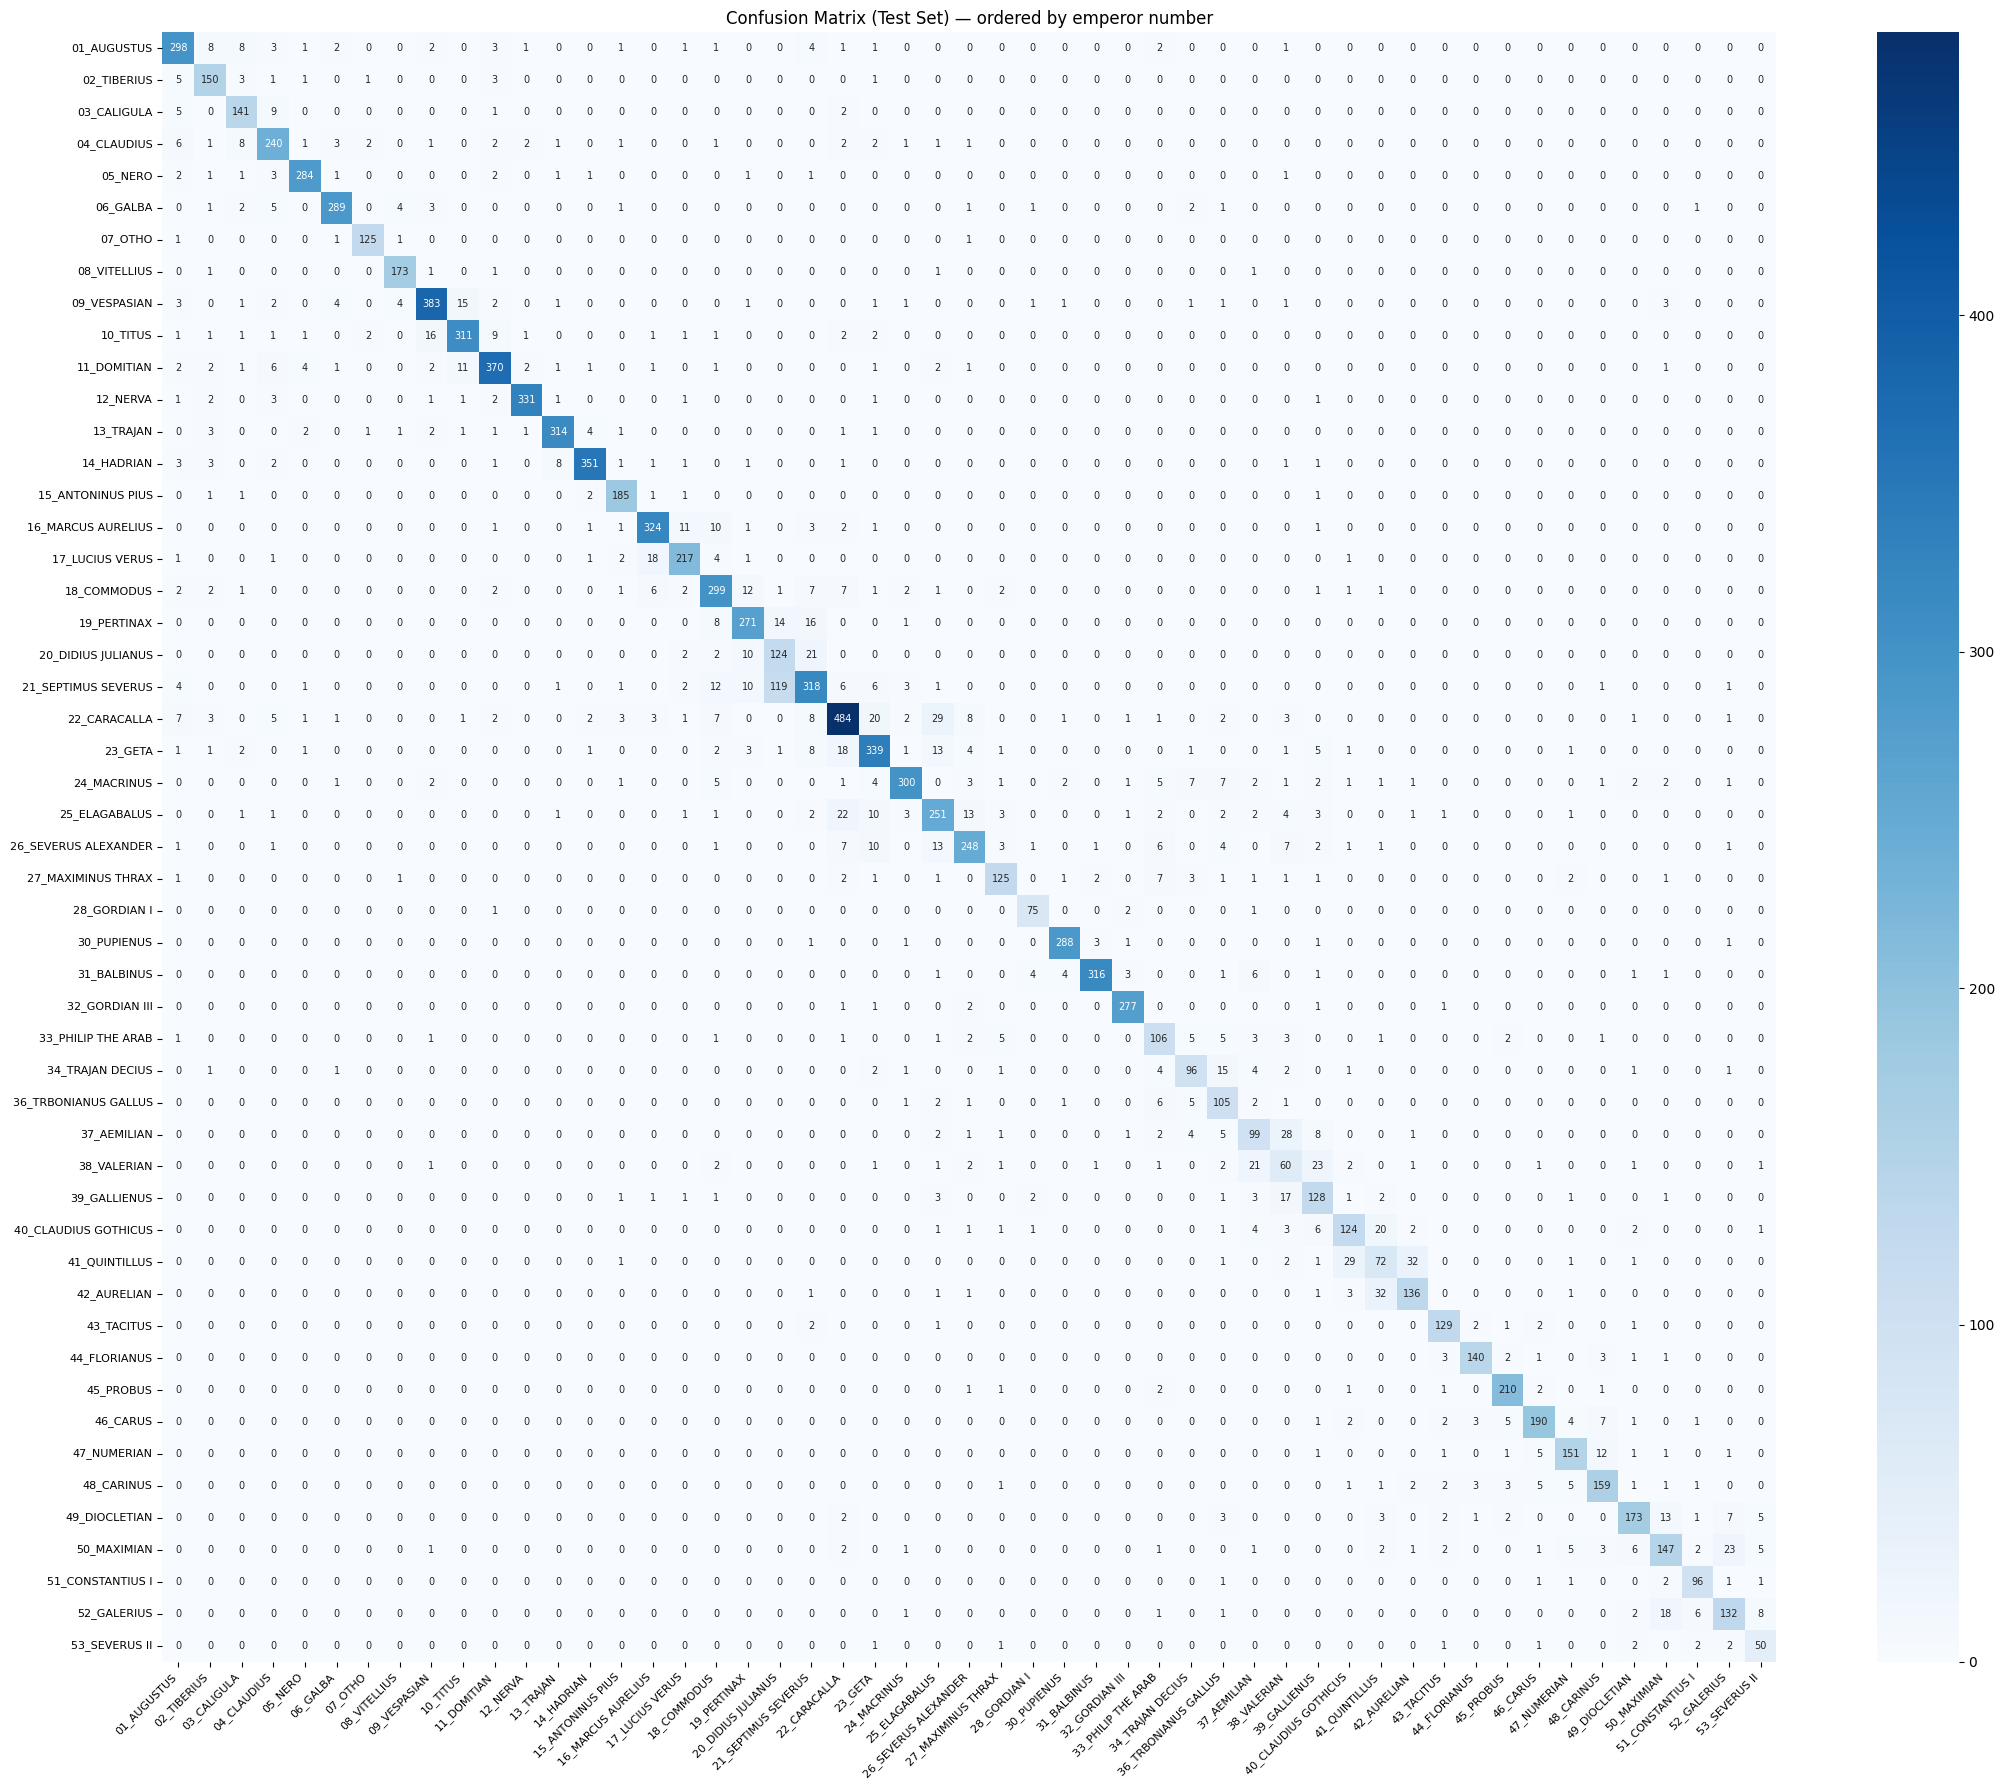

In [12]:
# Confusion matrix on the test set, ordered by emperor number ("01_AUGUSTUS" -> "53_SEVERUS II")

# Map each (prefix-stripped) class name back to its numeric folder prefix.
name_to_prefix = {
    re.sub(r'^\d+_', '', p.name): int(re.match(r'^(\d+)_', p.name).group(1))
    for p in Path(DATA_DIR).iterdir()
    if p.is_dir() and (p / 'side_a').exists()
}
class_order = sorted(range(num_classes), key=lambda i: name_to_prefix[idx_to_label[i]])
display_names = [f"{name_to_prefix[idx_to_label[i]]:02d}_{idx_to_label[i]}" for i in class_order]

head.eval()
cm = np.zeros((num_classes, num_classes), dtype=int)
with torch.no_grad():
    for feats, targets in test_loader:
        feats, targets = feats.to(device), targets.to(device)
        _, preds = torch.max(head(feats), 1)
        for t, p in zip(targets.cpu(), preds.cpu()):
            cm[t.item(), p.item()] += 1

# Reorder rows and columns so the matrix reads chronologically by emperor number
cm = cm[np.ix_(class_order, class_order)]

df_cm = pd.DataFrame(cm, index=display_names, columns=display_names)

plt.figure(figsize=(22, 18))
sns.heatmap(df_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=display_names, yticklabels=display_names,
            annot_kws={'size': 7})
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.title('Confusion Matrix (Test Set) — ordered by emperor number')
plt.tight_layout()
plt.show()


In [13]:
# Confusion matrix as plain text — easy to copy and paste into an LLM chat.
# Reuses `cm`, `display_names`, `num_classes` from the previous cell (already ordered chronologically).
TOP_CONFUSIONS = 3  # how many wrong predictions to list per true class

total_correct = int(cm.diagonal().sum())
total = int(cm.sum())
print(f'Overall test accuracy: {total_correct}/{total} = {total_correct/total:.4f}')
print(f'Classes: {num_classes}\n')

row_acc = cm.diagonal() / cm.sum(axis=1).clip(min=1)
order_worst_first = np.argsort(row_acc)  # worst-performing classes first — most useful for analysis

print('Per-class breakdown (sorted by accuracy, worst first):')
for i in order_worst_first:
    n_total = int(cm[i].sum())
    n_correct = int(cm[i, i])
    acc = n_correct / max(n_total, 1)
    print(f'\n{display_names[i]}: {n_correct}/{n_total} correct  acc={acc:.3f}')
    off = sorted(
        ((j, int(cm[i, j])) for j in range(num_classes) if j != i and cm[i, j] > 0),
        key=lambda x: -x[1],
    )
    if not off:
        print('  (no mistakes)')
        continue
    for j, count in off[:TOP_CONFUSIONS]:
        print(f'  -> predicted as {display_names[j]}: {count} ({count / max(n_total, 1):.1%})')
    remaining = sum(c for _, c in off[TOP_CONFUSIONS:])
    if remaining:
        print(f'  -> other classes: {remaining}')


Overall test accuracy: 10704/12473 = 0.8582
Classes: 51

Per-class breakdown (sorted by accuracy, worst first):

38_VALERIAN: 60/122 correct  acc=0.492
  -> predicted as 39_GALLIENUS: 23 (18.9%)
  -> predicted as 37_AEMILIAN: 21 (17.2%)
  -> predicted as 18_COMMODUS: 2 (1.6%)
  -> other classes: 16

41_QUINTILLUS: 72/140 correct  acc=0.514
  -> predicted as 42_AURELIAN: 32 (22.9%)
  -> predicted as 40_CLAUDIUS GOTHICUS: 29 (20.7%)
  -> predicted as 38_VALERIAN: 2 (1.4%)
  -> other classes: 5

37_AEMILIAN: 99/152 correct  acc=0.651
  -> predicted as 38_VALERIAN: 28 (18.4%)
  -> predicted as 39_GALLIENUS: 8 (5.3%)
  -> predicted as 36_TRBONIANUS GALLUS: 5 (3.3%)
  -> other classes: 12

21_SEPTIMUS SEVERUS: 318/486 correct  acc=0.654
  -> predicted as 20_DIDIUS JULIANUS: 119 (24.5%)
  -> predicted as 18_COMMODUS: 12 (2.5%)
  -> predicted as 19_PERTINAX: 10 (2.1%)
  -> other classes: 27

50_MAXIMIAN: 147/203 correct  acc=0.724
  -> predicted as 52_GALERIUS: 23 (11.3%)
  -> predicted as 49_

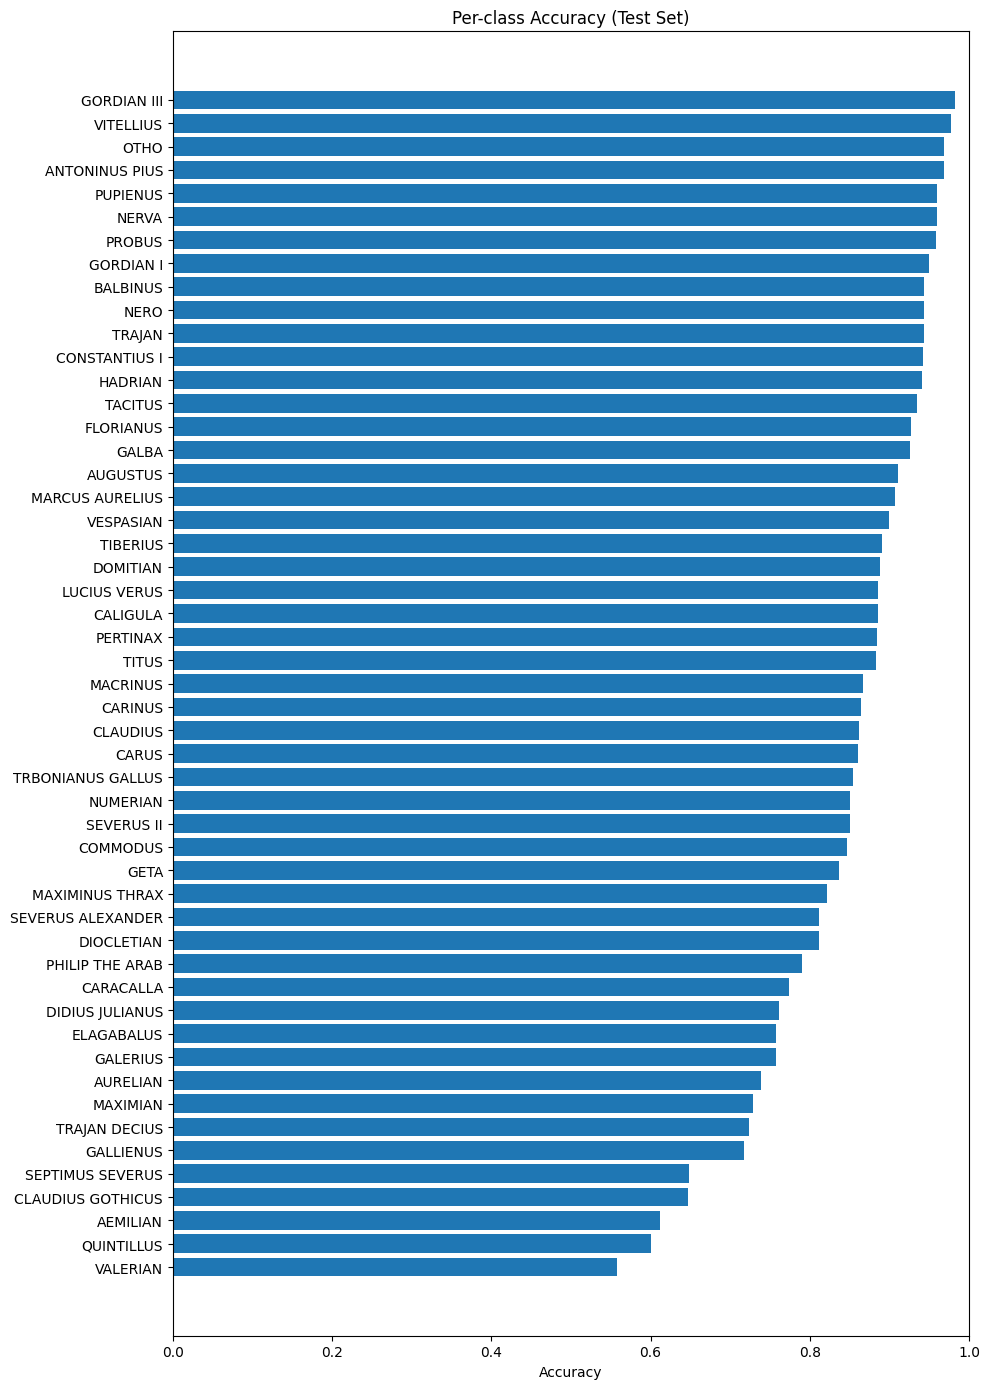

          Emperor  Accuracy
         VALERIAN  0.557377
       QUINTILLUS  0.600000
         AEMILIAN  0.611842
CLAUDIUS GOTHICUS  0.646707
 SEPTIMUS SEVERUS  0.648148
        GALLIENUS  0.717791
    TRAJAN DECIUS  0.723077
         MAXIMIAN  0.729064
         AURELIAN  0.738636
         GALERIUS  0.757396
       ELAGABALUS  0.757669
  DIDIUS JULIANUS  0.761006
        CARACALLA  0.773869
  PHILIP THE ARAB  0.789855
       DIOCLETIAN  0.811321
SEVERUS ALEXANDER  0.811688
  MAXIMINUS THRAX  0.821192
             GETA  0.837037
         COMMODUS  0.846154
       SEVERUS II  0.850000
         NUMERIAN  0.850575
TRBONIANUS GALLUS  0.854839
            CARUS  0.861111
         CLAUDIUS  0.862319
          CARINUS  0.864865
         MACRINUS  0.867232
            TITUS  0.883191
         PERTINAX  0.883871
         CALIGULA  0.886076
     LUCIUS VERUS  0.886179
         DOMITIAN  0.887805
         TIBERIUS  0.890909
        VESPASIAN  0.899061
  MARCUS AURELIUS  0.907303
         AUGUSTUS  0

In [24]:
# Per-class accuracy from the confusion matrix
per_class_acc = cm.diagonal() / cm.sum(axis=1).clip(min=1)
acc_df = pd.DataFrame({'Emperor': class_names, 'Accuracy': per_class_acc}).sort_values('Accuracy')

plt.figure(figsize=(10, 14))
plt.barh(acc_df['Emperor'], acc_df['Accuracy'])
plt.xlabel('Accuracy')
plt.title('Per-class Accuracy (Test Set)')
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

print(acc_df.to_string(index=False))